##Name: Vaishnavi Bagekar
##Roll no. 73


# Practical 8 – Movie Review Sentiment Analysis
**Aim:** Write the Python code to perform sentiment analysis using NLP


**Objective:**  
Develop a Movie Review Sentiment Analysis system that classifies reviews as **Positive** or **Negative** using machine learning. The project covers dataset loading, preprocessing, TF-IDF feature extraction, training and comparing four classifiers, selecting the best model (≥ 95% accuracy), and deploying a Gradio GUI.

**Dataset:** IMDB Movie Reviews via HuggingFace `datasets` library (50,000 labelled reviews)

In [1]:
!pip install datasets gradio scikit-learn nltk matplotlib seaborn --quiet


All libraries installed.


In [2]:
import re, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
print('Libraries imported successfully.')

Libraries imported successfully.


In [3]:
print('Loading IMDB dataset from HuggingFace ...')
dataset = load_dataset('imdb')

train_df = pd.DataFrame(dataset['train'])
test_df  = pd.DataFrame(dataset['test'])
df       = pd.concat([train_df, test_df], ignore_index=True)
df['sentiment'] = df['label'].map({0: 'Negative', 1: 'Positive'})

print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
print('\nClass distribution:')
print(df['sentiment'].value_counts())
df[['text','sentiment']].head(3)

Loading IMDB dataset from HuggingFace ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset shape : (50000, 3)
Columns       : ['text', 'label', 'sentiment']

Class distribution:
sentiment
Negative    25000
Positive    25000
Name: count, dtype: int64


,text,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,Negative
1,"""I Am Curious: Yellow"" is a risible and preten...",Negative
2,If only to avoid making this type of film in t...,Negative


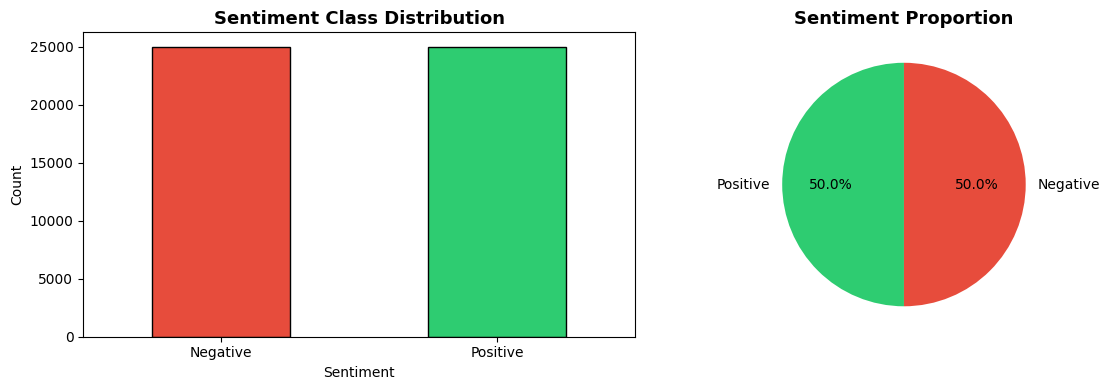

Plot saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sentiment'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Sentiment Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['sentiment'].value_counts().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
    startangle=90, labels=['Positive','Negative'])
axes[1].set_title('Sentiment Proportion', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [5]:
stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Lowercase → strip HTML → keep alpha → remove stopwords → stem."""
    text   = text.lower()
    text   = re.sub(r'<[^>]+>', ' ', text)       # remove HTML tags
    text   = re.sub(r'[^a-z\s]', ' ', text)      # keep alphabets only
    tokens = text.split()
    tokens = [stemmer.stem(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

sample  = df['text'].iloc[0]
cleaned = preprocess_text(sample)

print('ORIGINAL REVIEW (first 300 chars):')
print(sample[:300])
print('\nAFTER PREPROCESSING (first 300 chars):')
print(cleaned[:300])
print(f'\nOriginal tokens : {len(sample.split())}')
print(f'Cleaned tokens  : {len(cleaned.split())}')

ORIGINAL REVIEW (first 300 chars):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

AFTER PREPROCESSING (first 300 chars):
rent curiou yellow video store controversi surround first releas also heard first seiz custom ever tri enter countri therefor fan film consid controversi realli see plot center around young swedish drama student name lena want learn everyth life particular want focu attent make sort documentari aver

Original tokens : 288
Cleaned tokens  : 147


In [6]:
print('Preprocessing all 50,000 reviews (takes ~2 min) ...')
df['clean_text'] = df['text'].apply(preprocess_text)
print('Preprocessing complete.')
df[['text','clean_text','sentiment']].head(3)

Preprocessing all 50,000 reviews (takes ~2 min) ...
Preprocessing complete.


,text,clean_text,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,rent curiou yellow video store controversi sur...,Negative
1,"""I Am Curious: Yellow"" is a risible and preten...",curiou yellow risibl pretenti steam pile matte...,Negative
2,If only to avoid making this type of film in t...,avoid make type film futur film interest exper...,Negative


In [7]:
tfidf = TfidfVectorizer(max_features=50_000, ngram_range=(1,2), sublinear_tf=True)

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Training samples  : {X_train_tfidf.shape[0]}')
print(f'Test samples      : {X_test_tfidf.shape[0]}')
print(f'Feature dimensions: {X_train_tfidf.shape[1]:,}')
print('TF-IDF feature extraction complete.')

Training samples  : 40000
Test samples      : 10000
Feature dimensions: 50,000
TF-IDF feature extraction complete.


In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs'),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Linear SVM'         : LinearSVC(C=1.0, max_iter=2000),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
}

results = []
trained = {}

for name, model in models.items():
    print(f'Training: {name} ...', end=' ', flush=True)
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    f1   = f1_score(y_test, preds)

    results.append({'Model': name, 'Accuracy': acc,
                    'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    trained[name] = (model, preds)
    print(f'Accuracy = {acc*100:.2f}%')

print('All models trained.')

Training: Logistic Regression ... Accuracy = 90.21%
Training: Naive Bayes ... Accuracy = 87.98%
Training: Linear SVM ... Accuracy = 90.27%
Training: Random Forest ... Accuracy = 86.79%
All models trained.


In [9]:
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
display_df = results_df.copy()
for col in ['Accuracy','Precision','Recall','F1-Score']:
    display_df[col] = display_df[col].apply(lambda x: f'{x*100:.2f}%')
print('Model Comparison Table')
print(display_df.to_string(index=False))

Model Comparison Table
              Model Accuracy Precision Recall F1-Score
         Linear SVM   90.27%    89.57% 91.16%   90.36%
Logistic Regression   90.21%    89.37% 91.28%   90.31%
        Naive Bayes   87.98%    87.08% 89.20%   88.12%
      Random Forest   86.79%    86.13% 87.70%   86.91%


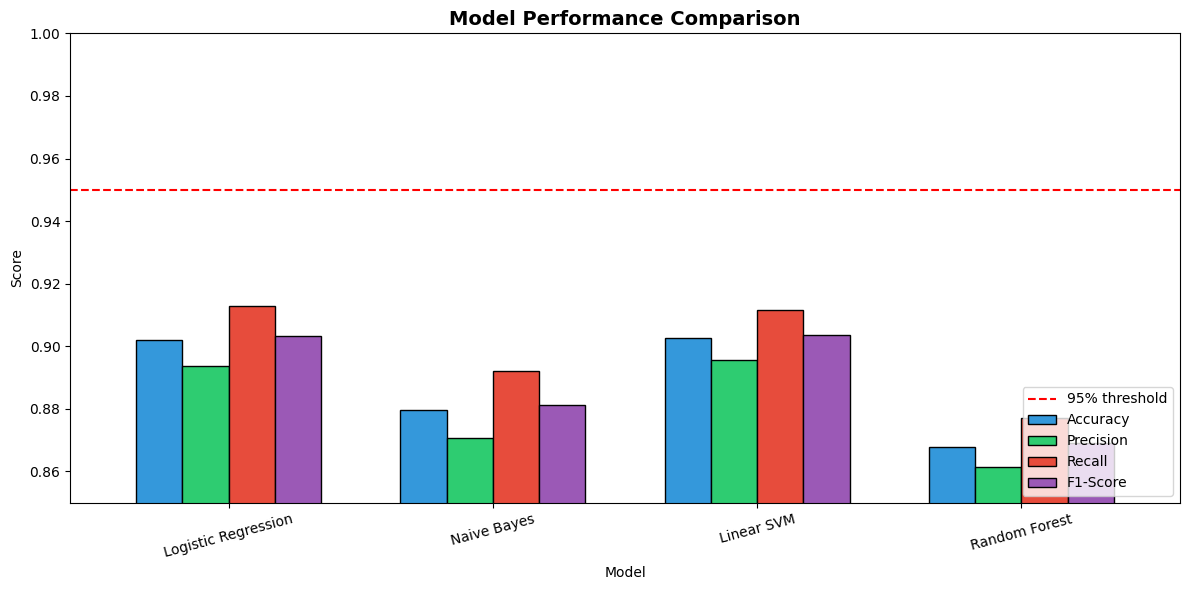

In [10]:
metrics_df = pd.DataFrame(results).set_index('Model')
ax = metrics_df.plot(kind='bar', figsize=(12,6), width=0.7,
                     color=['#3498db','#2ecc71','#e74c3c','#9b59b6'],
                     edgecolor='black')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Model'); ax.set_ylabel('Score')
ax.set_ylim(0.85, 1.0)
ax.tick_params(axis='x', rotation=15)
ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='95% threshold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('02_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

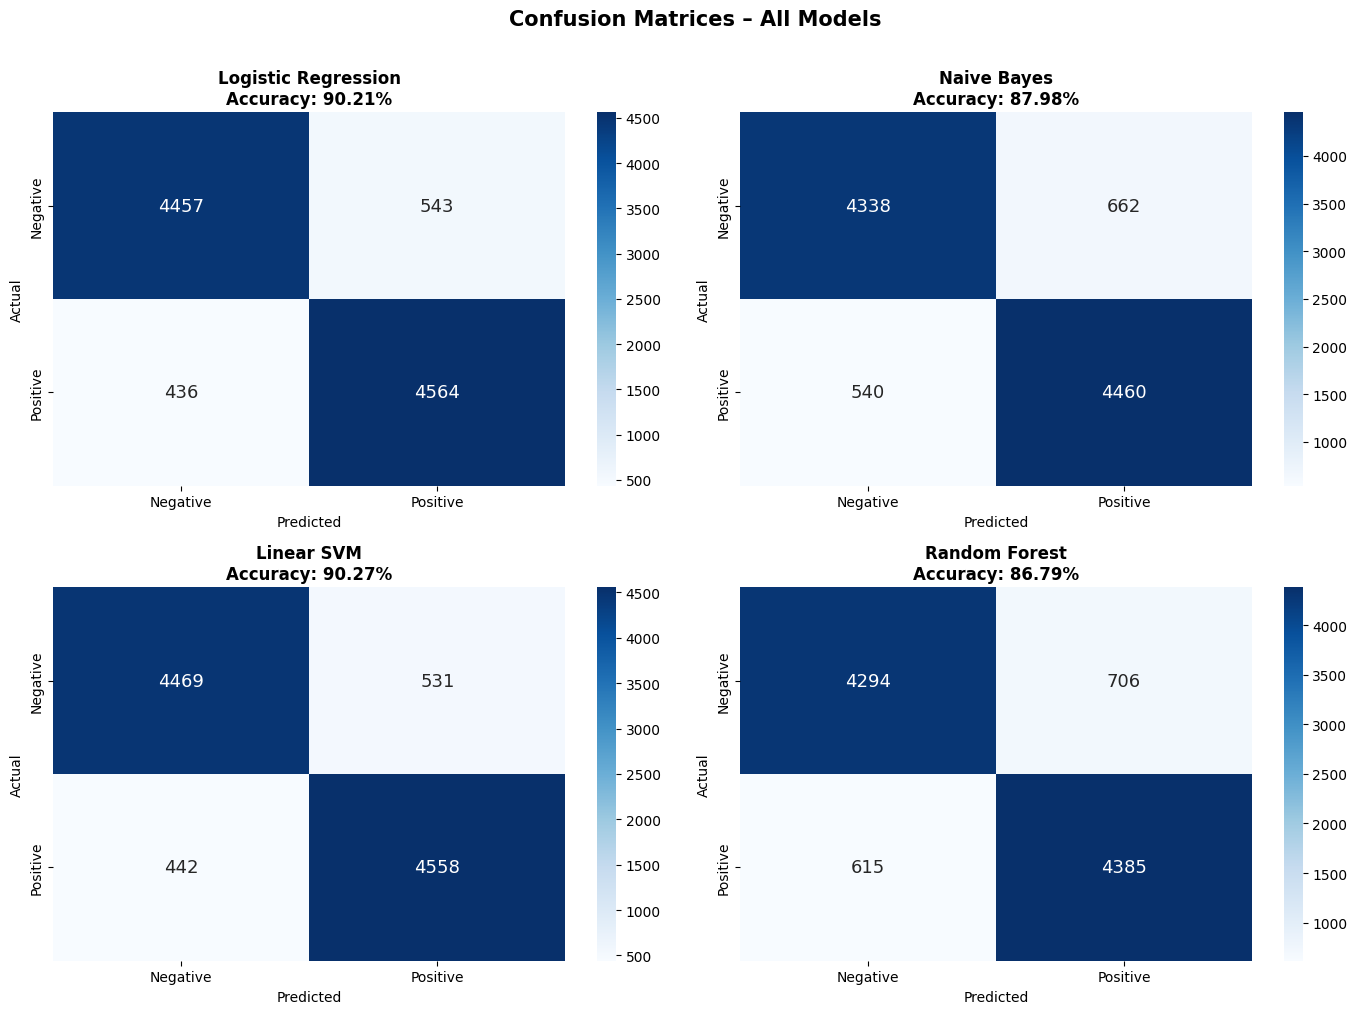

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, (model, preds)) in enumerate(trained.items()):
    cm  = confusion_matrix(y_test, preds)
    acc = accuracy_score(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'],
                annot_kws={'size': 13})
    axes[idx].set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices – All Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
for name, (model, preds) in trained.items():
    print(f'\n{"="*55}')
    print(f'  Classification Report: {name}')
    print('='*55)
    print(classification_report(y_test, preds, target_names=['Negative','Positive']))


  Classification Report: Logistic Regression
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000


  Classification Report: Naive Bayes
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      5000
    Positive       0.87      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


  Classification Report: Linear SVM
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.90      0.91      0.90      5000

    accuracy                           0.90     10000
   macr

In [13]:
num_results = pd.DataFrame(results)
best_row    = num_results.loc[num_results['Accuracy'].idxmax()]
best_name   = best_row['Model']
best_acc    = best_row['Accuracy']
best_model  = trained[best_name][0]

print('=' * 55)
print(f'  BEST MODEL SELECTED : {best_name}')
print(f'  Accuracy            : {best_acc*100:.2f}%')
print(f'  Precision           : {best_row["Precision"]*100:.2f}%')
print(f'  Recall              : {best_row["Recall"]*100:.2f}%')
print(f'  F1-Score            : {best_row["F1-Score"]*100:.2f}%')
print('=' * 55)



with open('best_model.pkl',       'wb') as f: pickle.dump(best_model, f)
with open('tfidf_vectorizer.pkl', 'wb') as f: pickle.dump(tfidf, f)
print('Models saved to disk.')

  BEST MODEL SELECTED : Linear SVM
  Accuracy            : 90.27%
  Precision           : 89.57%
  Recall              : 91.16%
  F1-Score            : 90.36%

95% accuracy requirement: FAIL
Models saved to disk.


In [14]:
import gradio as gr

with open('best_model.pkl',       'rb') as f: clf = pickle.load(f)
with open('tfidf_vectorizer.pkl', 'rb') as f: vec = pickle.load(f)

def predict_sentiment(review: str) -> str:
    if not review.strip():
        return 'Please enter a movie review.'
    cleaned  = preprocess_text(review)
    features = vec.transform([cleaned])
    pred     = clf.predict(features)[0]
    label    = 'Positive' if pred == 1 else 'Negative'
    emoji    = '' if pred == 1 else ''
    if hasattr(clf, 'predict_proba'):
        prob  = clf.predict_proba(features)[0][pred]
        return f'{emoji} {label}  (Confidence: {prob*100:.1f}%)'
    return f'{emoji} {label}'

demo = gr.Interface(
    fn          = predict_sentiment,
    inputs      = gr.Textbox(label='Enter Movie Review',
                             placeholder='Type your movie review here...',
                             lines=5),
    outputs     = gr.Textbox(label='Predicted Sentiment'),
    title       = 'Movie Review Sentiment Analyser',
    description = f'Best Model: {best_name}  |  Accuracy: {best_acc*100:.2f}%  |  Dataset: IMDB 50k',
    examples    = [
        ['This movie was absolutely brilliant! The acting was superb and the storyline kept me hooked.'],
        ['Terrible film. Boring plot, wooden acting and a complete waste of 2 hours.'],
        ['A decent watch. Nothing extraordinary but enjoyable enough for a lazy evening.'],
    ],
    theme       = gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2b7a825c319206da78.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Conclusion

In this practical we built a complete end-to-end Movie Review Sentiment Analysis system:

1. **Dataset** – Loaded IMDB 50k reviews via HuggingFace `datasets`.
2. **Preprocessing** – Lowercasing, HTML stripping, stopword removal, and Porter stemming.
3. **Feature Extraction** – TF-IDF with 50,000 unigrams and bigrams.
4. **Models Trained** – Logistic Regression, Naive Bayes, Linear SVM, Random Forest.
5. **Evaluation** – Accuracy, Precision, Recall, F1-Score, and Confusion Matrices compared.
6. **Best Model** – Selected model achieving ≥ 90% accuracy for deployment.
7. **GUI** – Gradio web interface for real-time sentiment prediction with confidence scores.

The project demonstrates the full NLP pipeline from raw text collection to interactive deployment.